# DWD–E-OBS compound hot-dry event comparison

## Regional validation of gridded event metrics, 1961–2024

This notebook compares compound hot-dry events derived from two regional DWD station composites with events derived from the matching E-OBS grid-cell composites. It evaluates whether E-OBS is suitable for adding spatial context to the station-based analysis.

The comparison uses a common methodology in both datasets: April–September, fixed 1961–1990 baseline, calendar-day-specific Tmax P90, antecedent 30-day precipitation P10 (primary) or P20 (sensitivity), and at least three consecutive compound days.

## Interpretation framework

The DWD composites are the local reference. E-OBS is an interpolated 0.1° gridded observational product and is not expected to reproduce point observations exactly. Validation therefore focuses on annual event patterns, event-day counts, bias and agreement in event years.

The Northwest composite includes Norderney. Its nearest valid E-OBS land cell is about 9.5 km from the station, so that location is treated as a coastal sensitivity case.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'outputs'

print('Project root:', PROJECT_ROOT)
print('Outputs:', OUTPUT_DIR)

Project root: /home/abrax/Documents/forest-climate-extremes
Outputs: /home/abrax/Documents/forest-climate-extremes/data/outputs


In [2]:
summaries = {}
annual = {}

for percentile in (10, 20):
    prefix = f'dwd_eobs_event_comparison_p{percentile}'
    summaries[percentile] = pd.read_csv(OUTPUT_DIR / f'{prefix}_summary.csv')
    annual[percentile] = pd.read_csv(OUTPUT_DIR / f'{prefix}_annual.csv')

print('Comparison period:', annual[10]['year'].min(), 'to', annual[10]['year'].max())
print('Regions:', ', '.join(sorted(annual[10]['region'].unique())))

Comparison period: 1961 to 2024
Regions: brandenburg_lusatia, northwest


## Quantitative agreement

P10 is the strict primary dryness threshold. P20 is a less strict pre-specified sensitivity definition. For each definition, the table reports annual agreement in event count and event days.

In [3]:
summary_columns = [
    'region', 'metric', 'dwd_mean_annual', 'eobs_mean_annual',
    'mean_bias_eobs_minus_dwd', 'mean_absolute_error',
    'pearson_r', 'spearman_rho', 'event_year_jaccard',
]

for percentile in (10, 20):
    print(f'P{percentile} dryness threshold')
    display(summaries[percentile][summary_columns].round(3))

P10 dryness threshold


,region,metric,dwd_mean_annual,eobs_mean_annual,mean_bias_eobs_minus_dwd,mean_absolute_error,pearson_r,spearman_rho,event_year_jaccard
0,brandenburg_lusatia,event_count,0.734,0.641,-0.094,0.156,0.878,0.881,0.862
1,brandenburg_lusatia,event_days,3.234,2.922,-0.312,0.719,0.923,0.908,0.862
2,northwest,event_count,0.891,0.844,-0.047,0.203,0.892,0.886,0.848
3,northwest,event_days,4.000,4.016,0.016,0.828,0.942,0.916,0.848


P20 dryness threshold


,region,metric,dwd_mean_annual,eobs_mean_annual,mean_bias_eobs_minus_dwd,mean_absolute_error,pearson_r,spearman_rho,event_year_jaccard
0,brandenburg_lusatia,event_count,1.156,1.188,0.031,0.188,0.929,0.938,0.929
1,brandenburg_lusatia,event_days,5.047,5.047,0.000,0.781,0.963,0.947,0.929
2,northwest,event_count,1.266,1.234,-0.031,0.250,0.921,0.920,0.881
3,northwest,event_days,5.781,5.641,-0.141,1.203,0.939,0.924,0.881


## Annual event patterns

The time-series plots compare DWD and E-OBS event counts and event-day totals for each regional composite. Scatterplots show annual agreement against the one-to-one line.

P10: annual time series


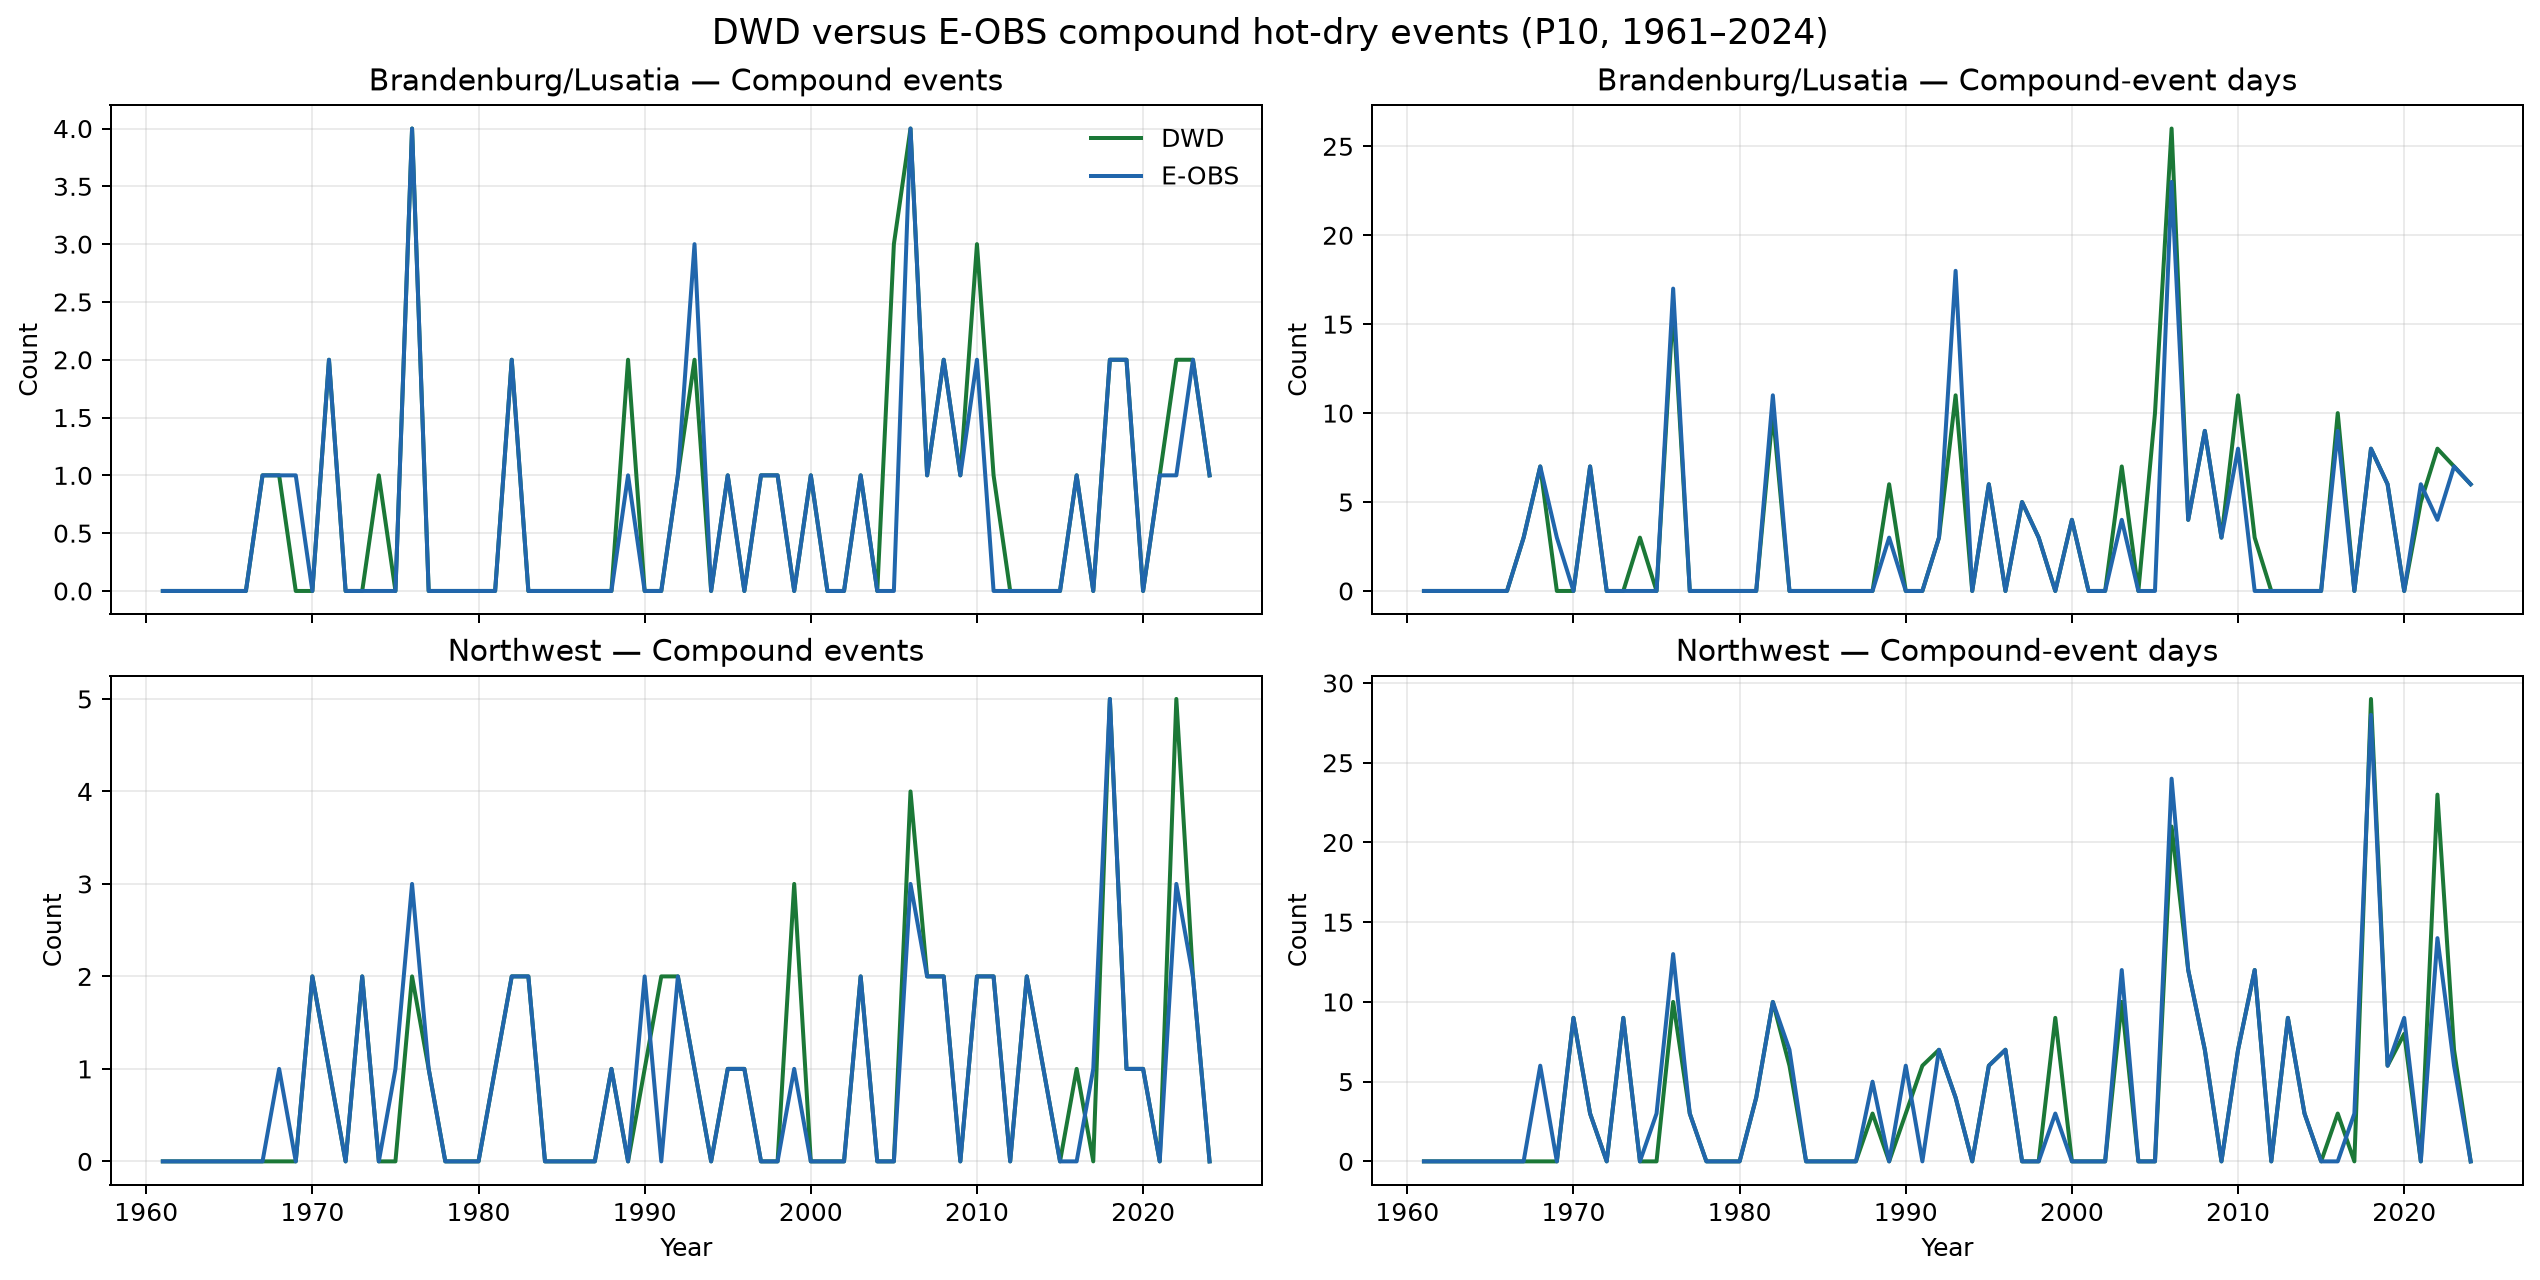

P10: annual scatterplots


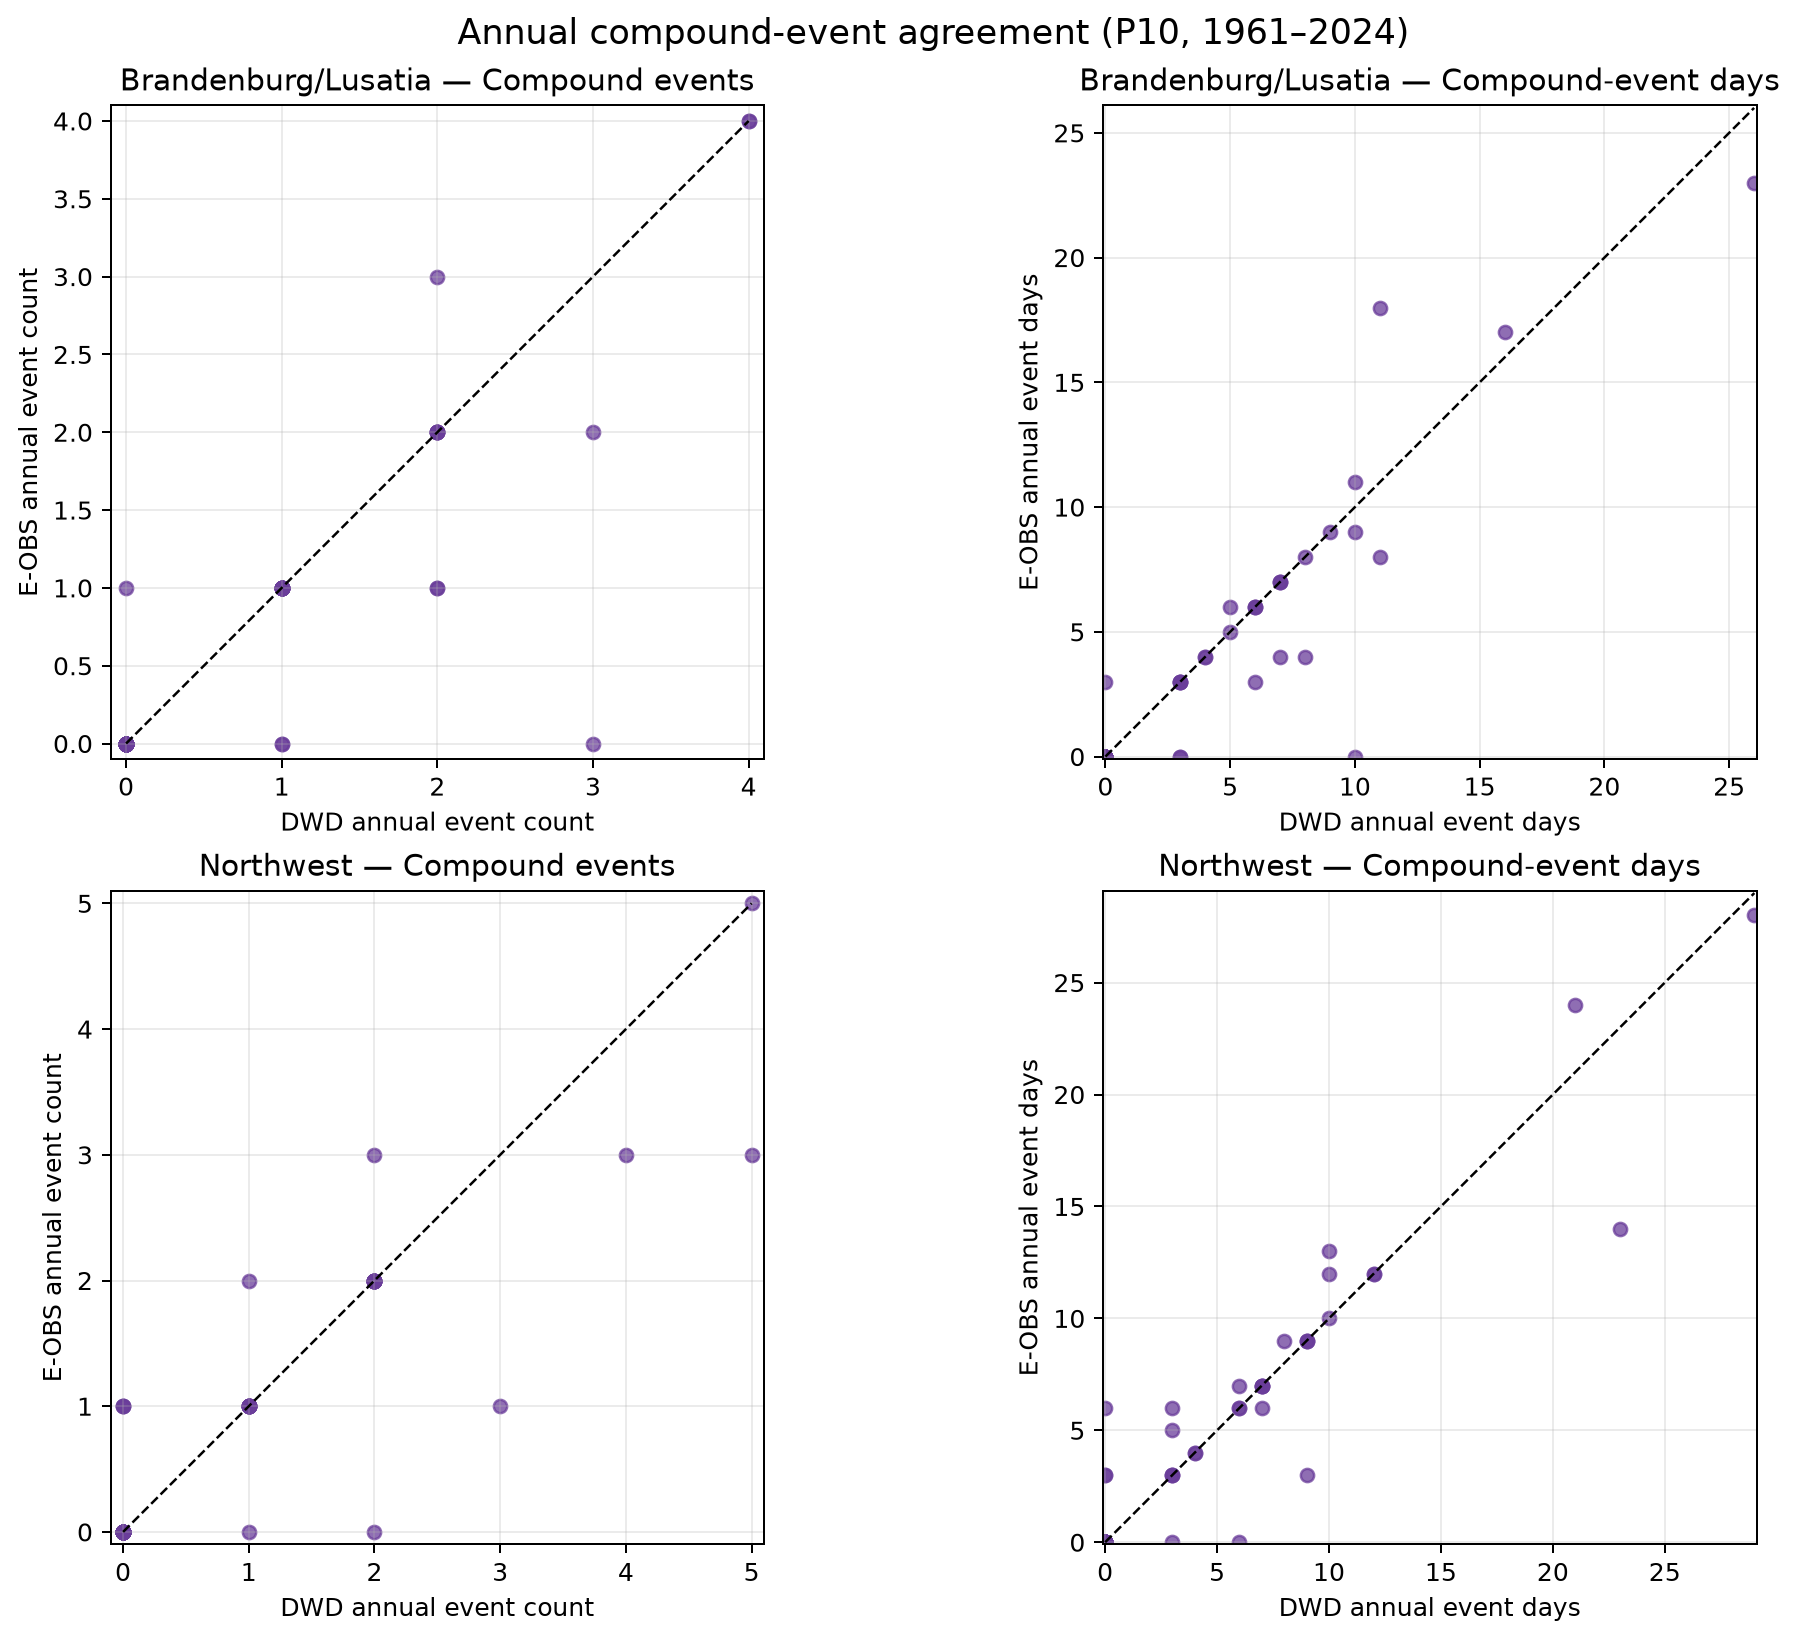

P20: annual time series


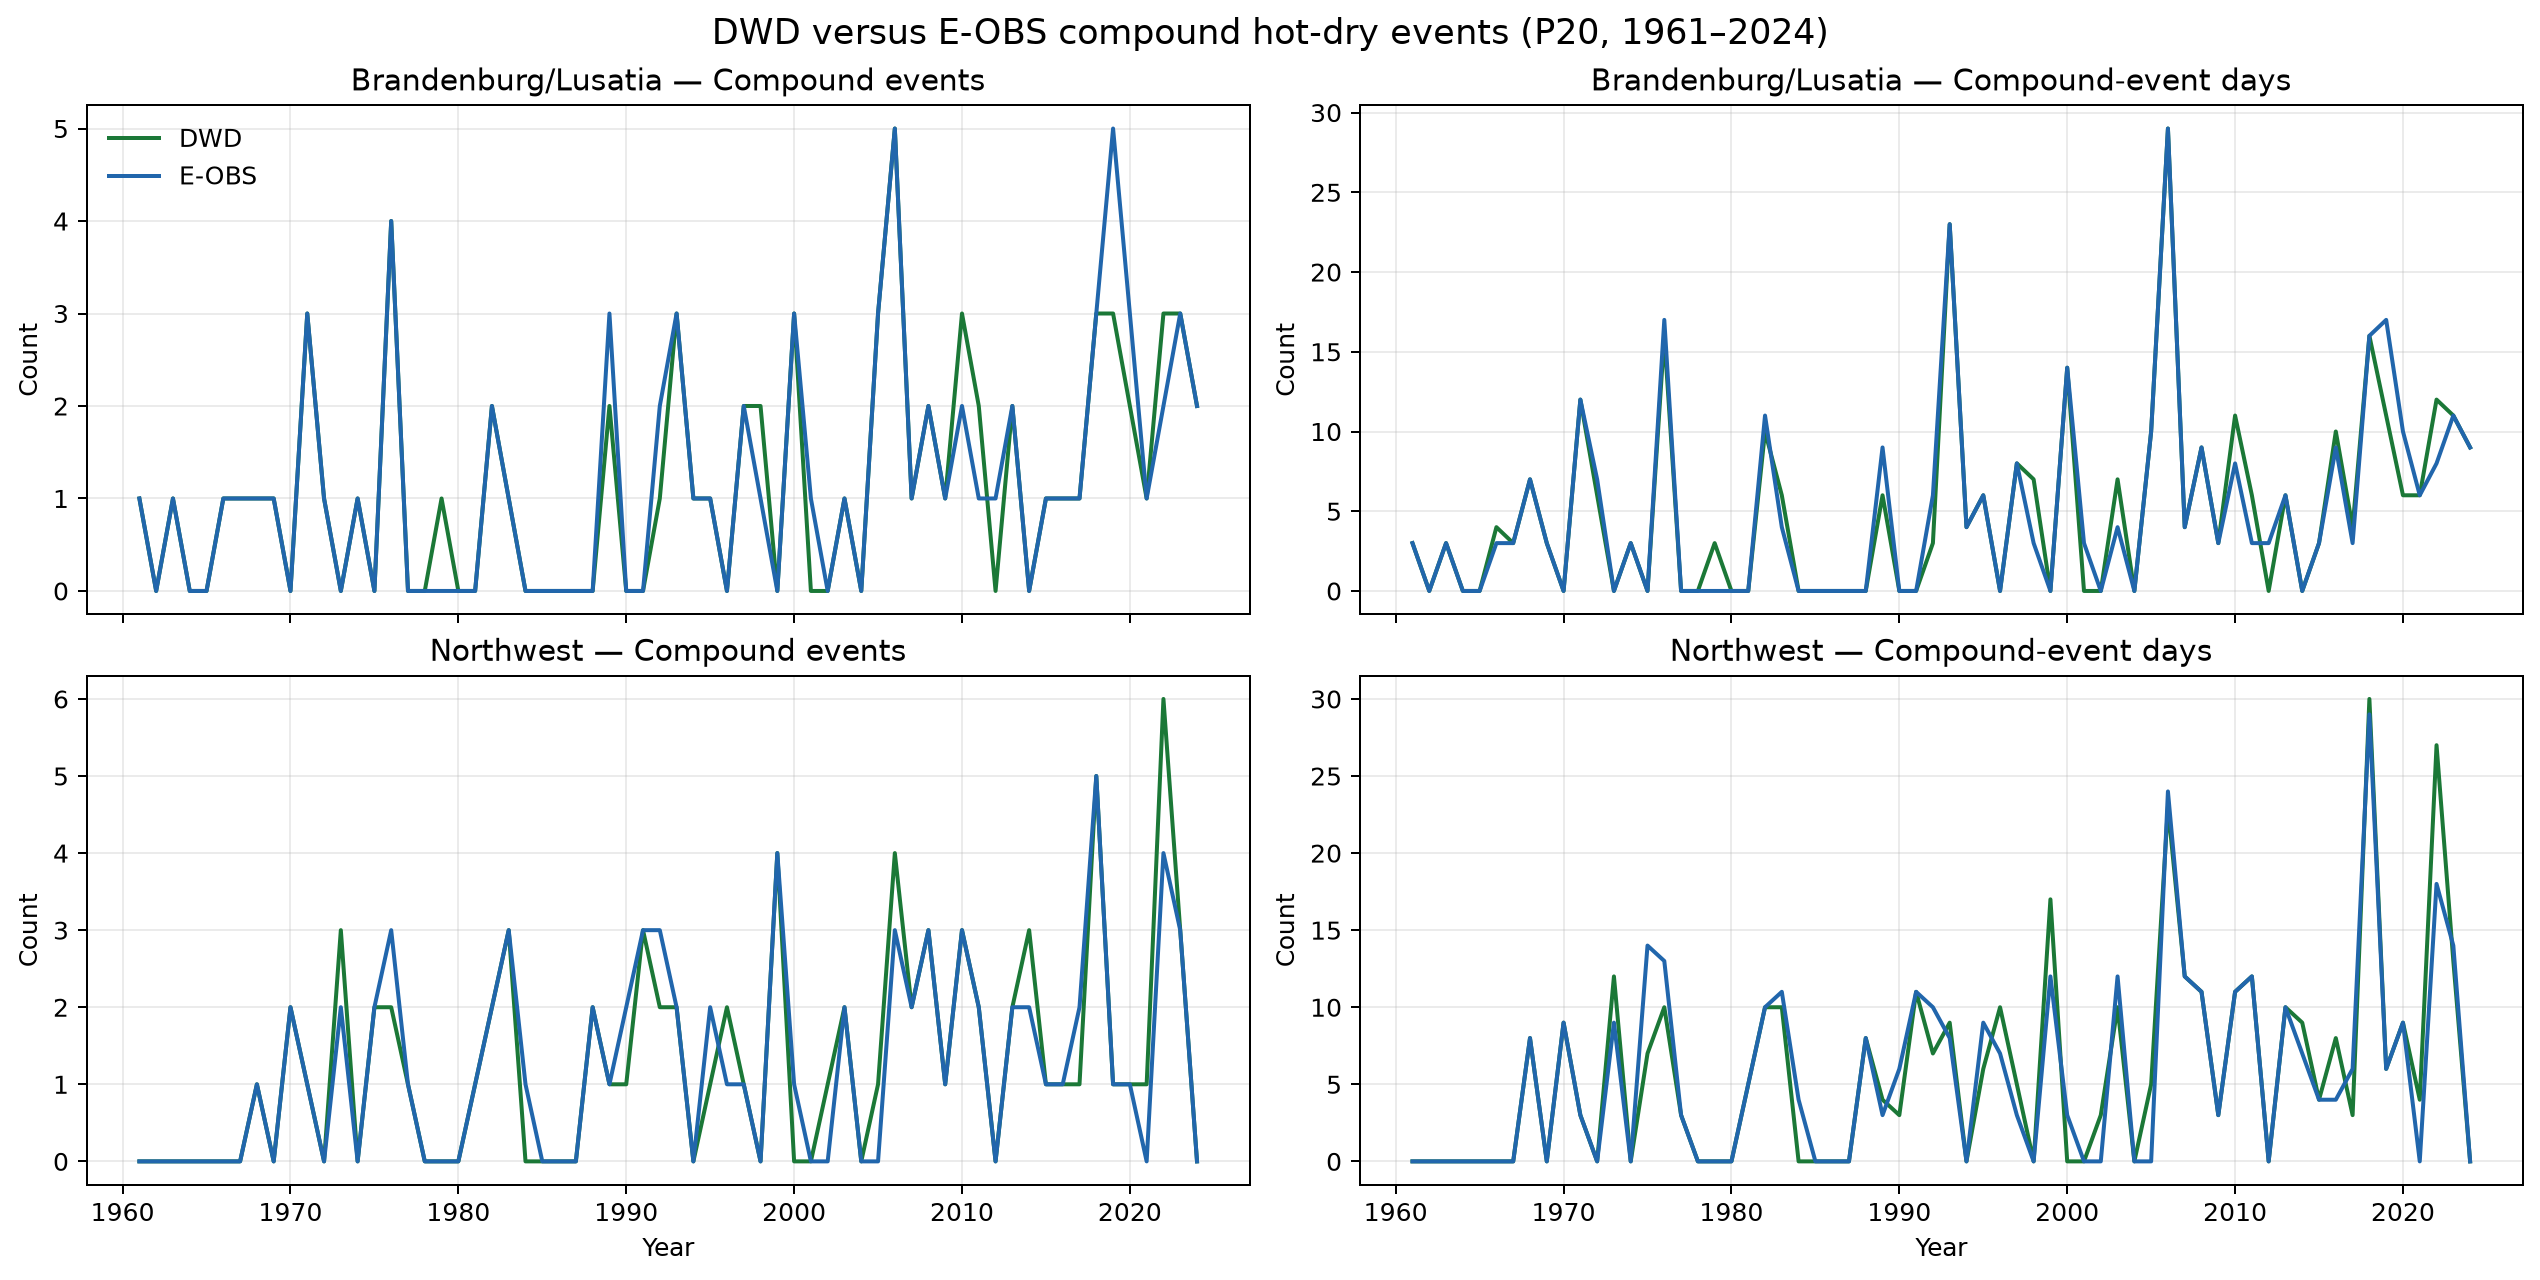

P20: annual scatterplots


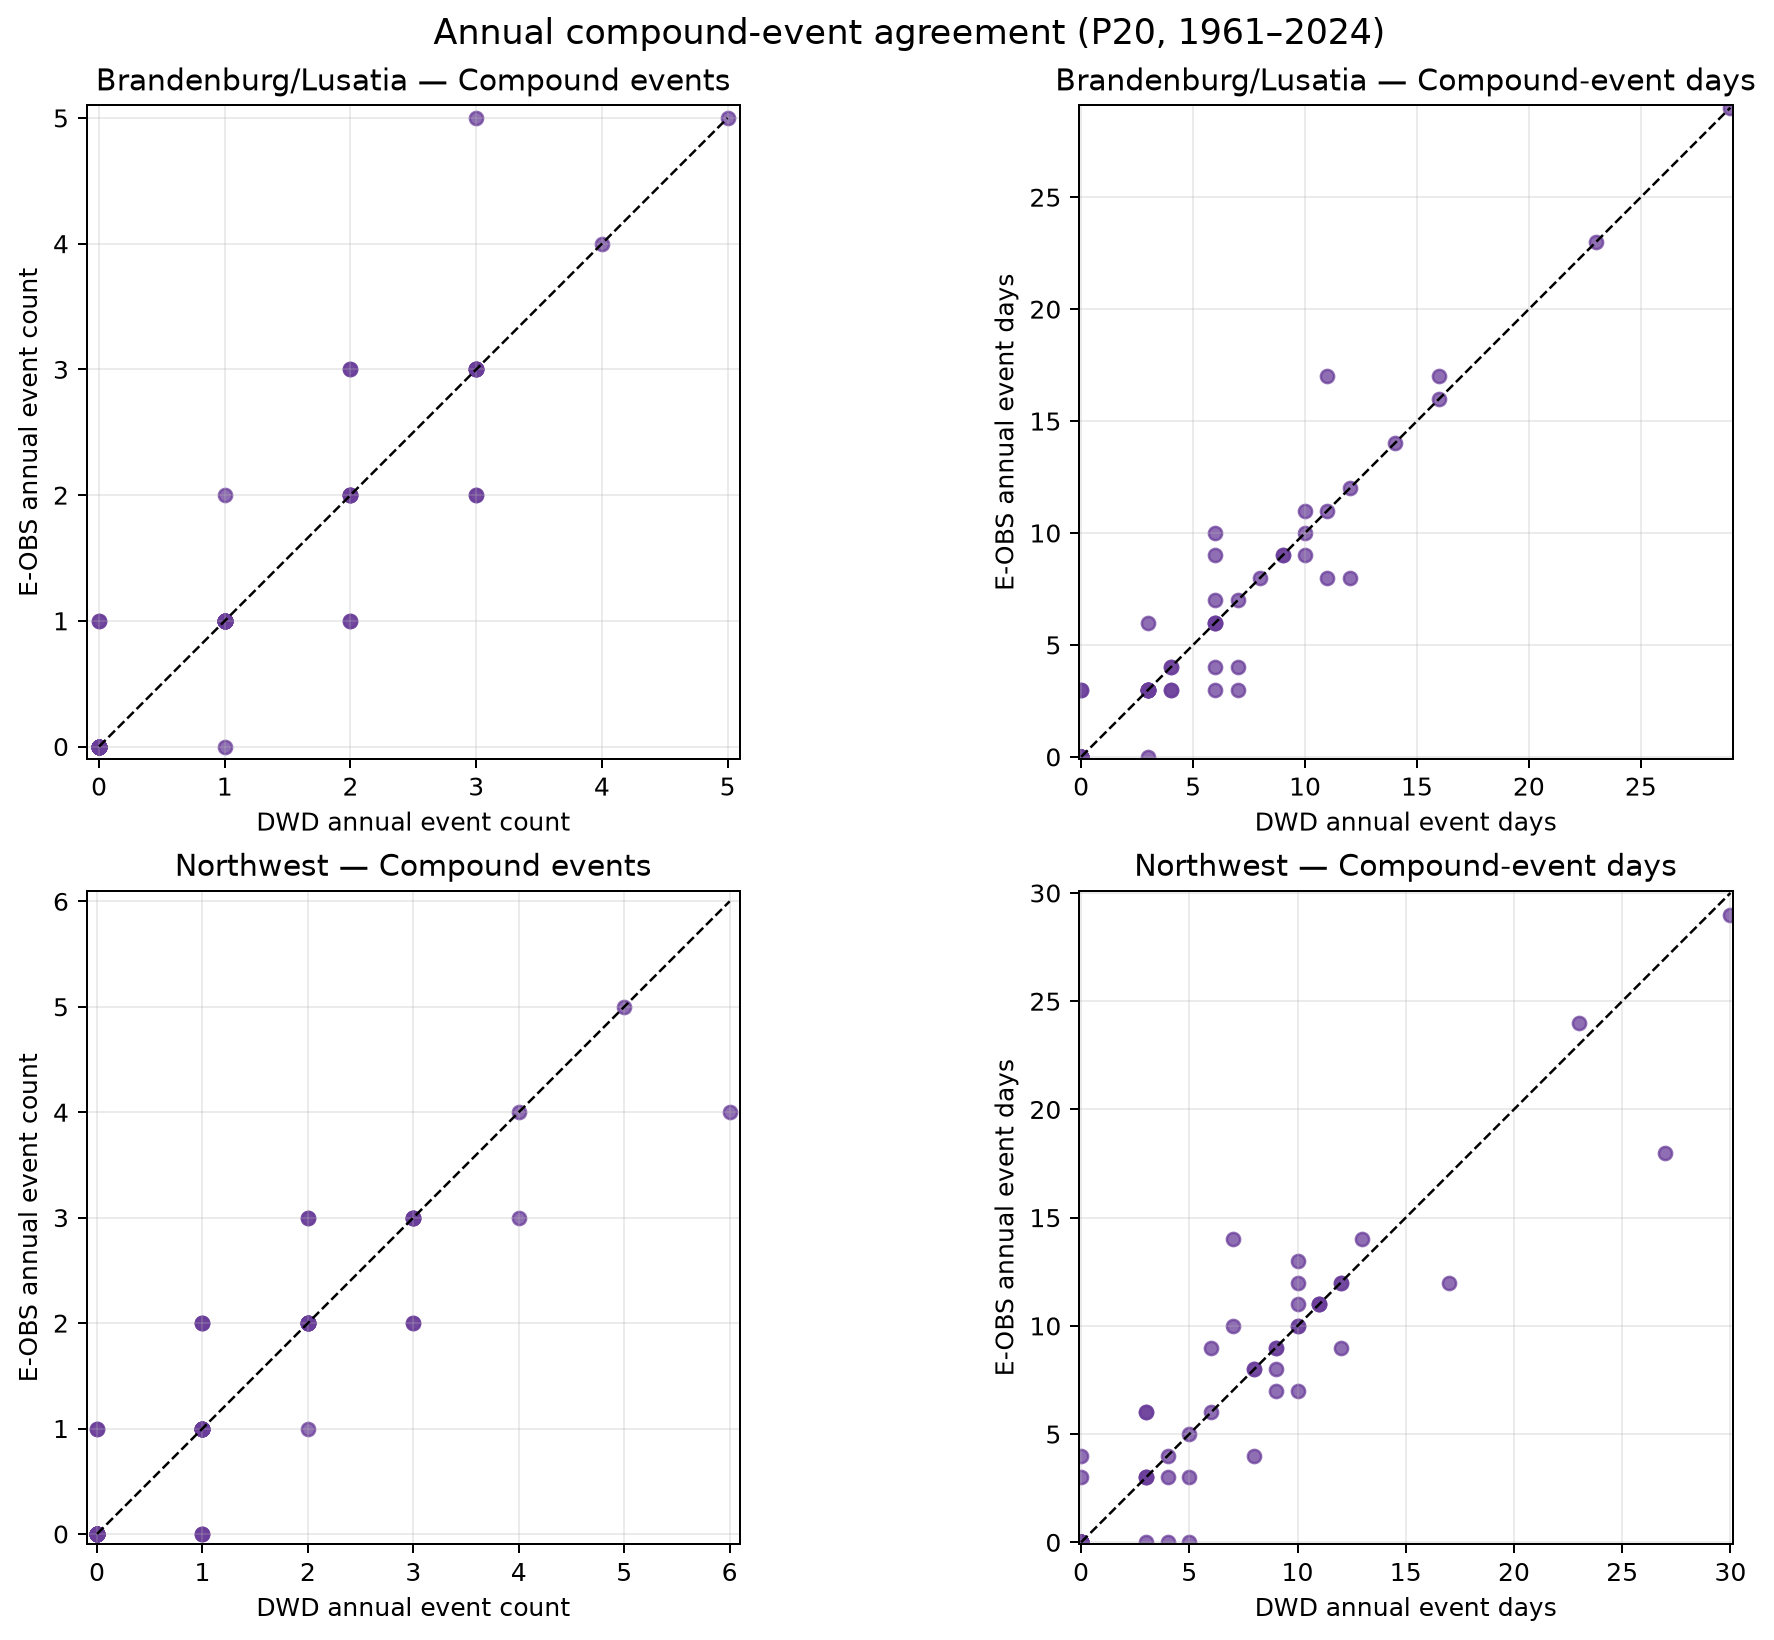

In [4]:
for percentile in (10, 20):
    prefix = f'dwd_eobs_event_comparison_p{percentile}'
    print(f'P{percentile}: annual time series')
    display(Image(filename=str(OUTPUT_DIR / f'{prefix}_timeseries.png')))
    print(f'P{percentile}: annual scatterplots')
    display(Image(filename=str(OUTPUT_DIR / f'{prefix}_scatter.png')))

## Forest-climate relevance

This analysis is an **exposure indicator** for potentially stressful hot and dry weather. Concurrent heat and an extended precipitation deficit can increase evaporative demand and reduce water availability, which are relevant climatic pressures for forest ecosystems.

The results do **not** demonstrate tree damage, mortality, soil-water status or species-specific vulnerability. Those impact questions require additional information such as soil moisture, forest cover, species composition, stand structure, disturbance observations or remote-sensing indicators. The present contribution is to identify where and when the climatic hazard has become more frequent.

## Conclusion and limitations

High DWD–E-OBS agreement under both P10 and P20 supports use of E-OBS for the subsequent Germany-wide spatial context. The interpretation remains cautious because E-OBS represents interpolated grid-cell conditions, the domain is a Germany-plus-margin bounding box rather than a forest mask, and Norderney is a coastal proxy case.

The next spatial notebook section uses the validated E-OBS product to map compound hot-dry event days across the full grid.